##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.rbm import restrictedBoltzmannMachine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as do do not need labels to 
    train the generative models. 
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)
# trainData = datasets.MNIST(root="../data", train=True, download=True) # , transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


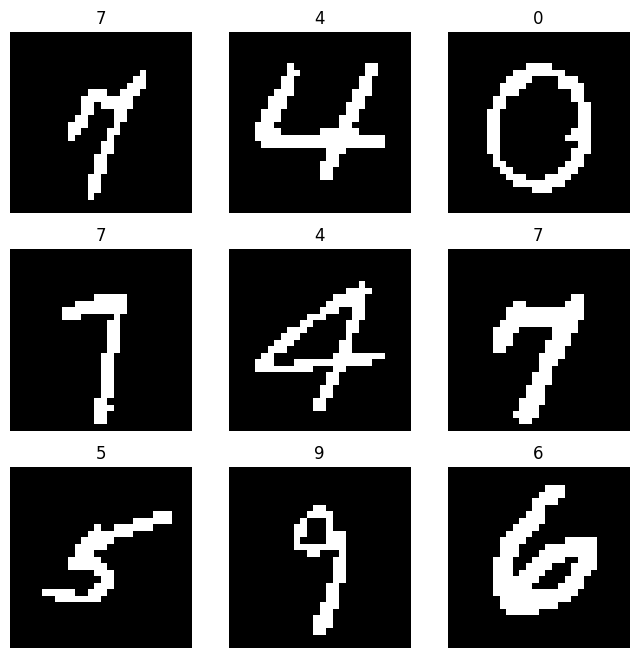

In [4]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [5]:
# inference
def plot_latent_space(n=30, figsize=15, scale=1.0):
    # display a n*n 2D manifold of digits
    digit_size = 28
    
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

###### Hardware Specs

In [6]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### MNIST

###### Variational Autoencoder

In [16]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [17]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [19]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [20]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 208.018204 reconLoss: 204.042679 klLoss: 3.975527[12800/60000]
totalLoss: 175.227844 reconLoss: 170.403595 klLoss: 4.824254[25600/60000]
totalLoss: 176.851624 reconLoss: 172.346558 klLoss: 4.505060[38400/60000]
totalLoss: 177.200226 reconLoss: 172.936951 klLoss: 4.263268[51200/60000]
Validation Error: 170.263649
Epoch 2
-------------------------------
totalLoss: 180.429749 reconLoss: 176.233749 klLoss: 4.195998[12800/60000]
totalLoss: 167.698700 reconLoss: 163.266953 klLoss: 4.431750[25600/60000]
totalLoss: 162.783157 reconLoss: 158.369675 klLoss: 4.413486[38400/60000]
totalLoss: 169.693802 reconLoss: 165.434036 klLoss: 4.259759[51200/60000]
Validation Error: 163.045332
Epoch 3
-------------------------------
totalLoss: 161.703552 reconLoss: 157.315460 klLoss: 4.388086[12800/60000]
totalLoss: 154.722000 reconLoss: 149.829956 klLoss: 4.892044[25600/60000]
totalLoss: 166.721558 reconLoss: 162.286789 klLoss: 4.434761[38400/60000]
totalLos

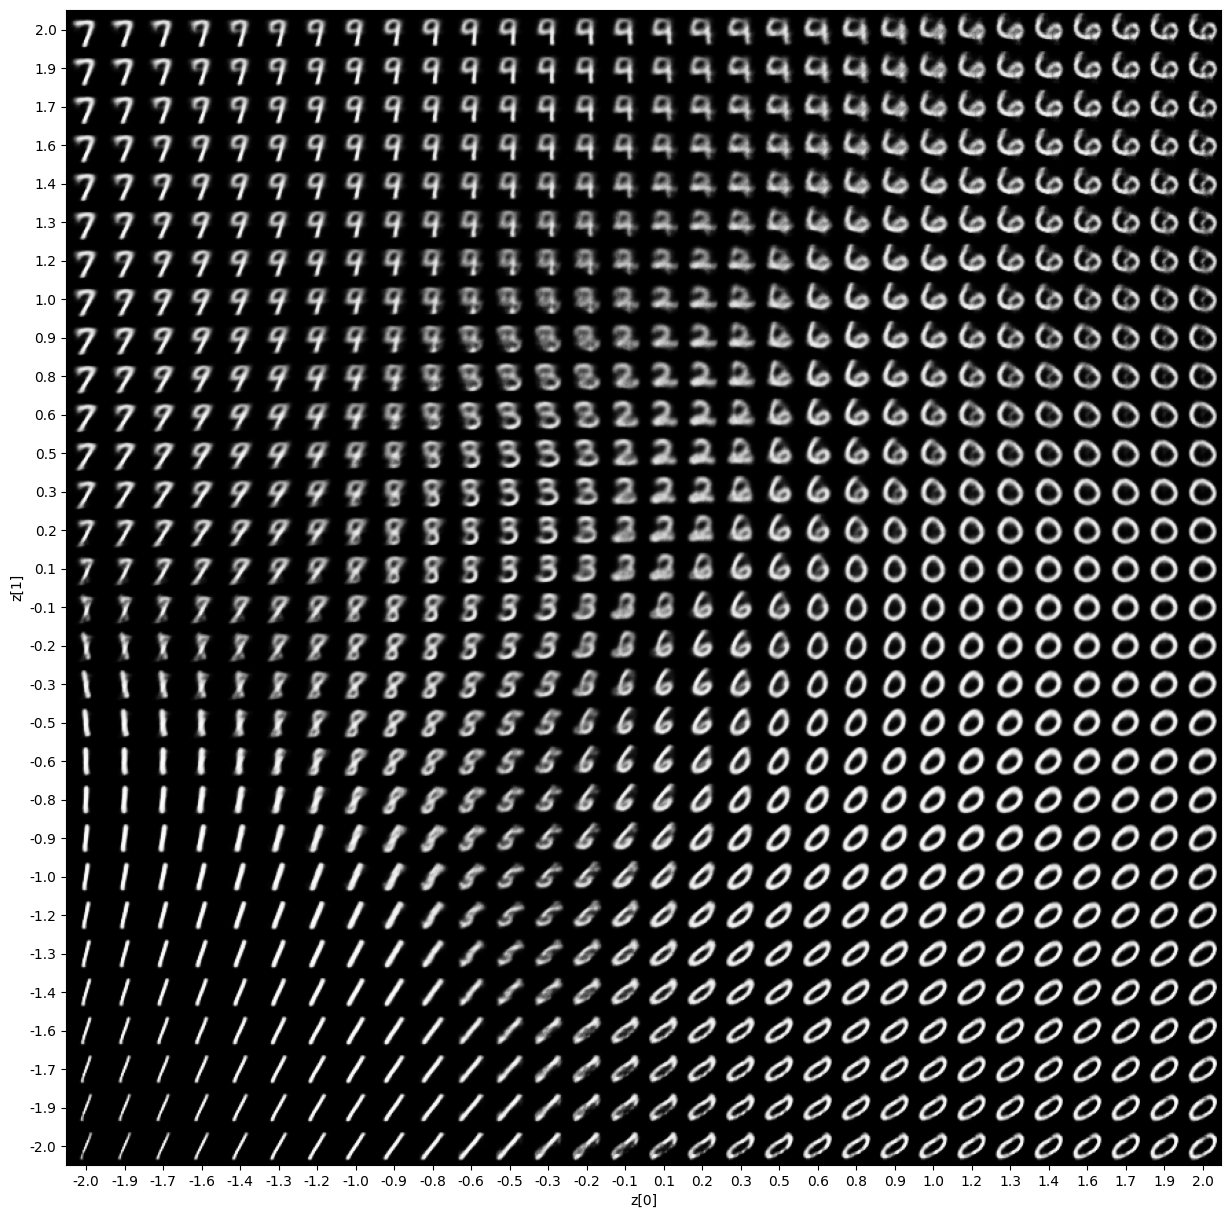

In [22]:
plot_latent_space(scale=2.0, n=30)

###### β-VAE

In [23]:
# build the encoder and decoder networks
hid_dim = 2
beta = 2.0

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder, beta).to(device)

In [24]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [25]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_bvae/',
                checkPointName='bvae_2_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 211.500732 reconLoss: 206.328918 klLoss: 2.585910[12800/60000]
totalLoss: 181.350586 reconLoss: 175.340073 klLoss: 3.005260[25600/60000]
totalLoss: 181.102509 reconLoss: 175.170990 klLoss: 2.965759[38400/60000]
totalLoss: 168.210922 reconLoss: 161.649750 klLoss: 3.280589[51200/60000]
Validation Error: 173.749889
Epoch 2
-------------------------------
totalLoss: 165.078629 reconLoss: 158.620041 klLoss: 3.229297[12800/60000]
totalLoss: 163.429672 reconLoss: 157.061813 klLoss: 3.183929[25600/60000]
totalLoss: 166.087936 reconLoss: 159.562439 klLoss: 3.262749[38400/60000]
totalLoss: 164.779068 reconLoss: 157.952744 klLoss: 3.413159[51200/60000]
Validation Error: 163.219700
Epoch 3
-------------------------------
totalLoss: 160.851166 reconLoss: 154.122345 klLoss: 3.364411[12800/60000]
totalLoss: 162.112427 reconLoss: 154.964081 klLoss: 3.574176[25600/60000]
totalLoss: 157.021301 reconLoss: 149.579300 klLoss: 3.721003[38400/60000]
totalLos

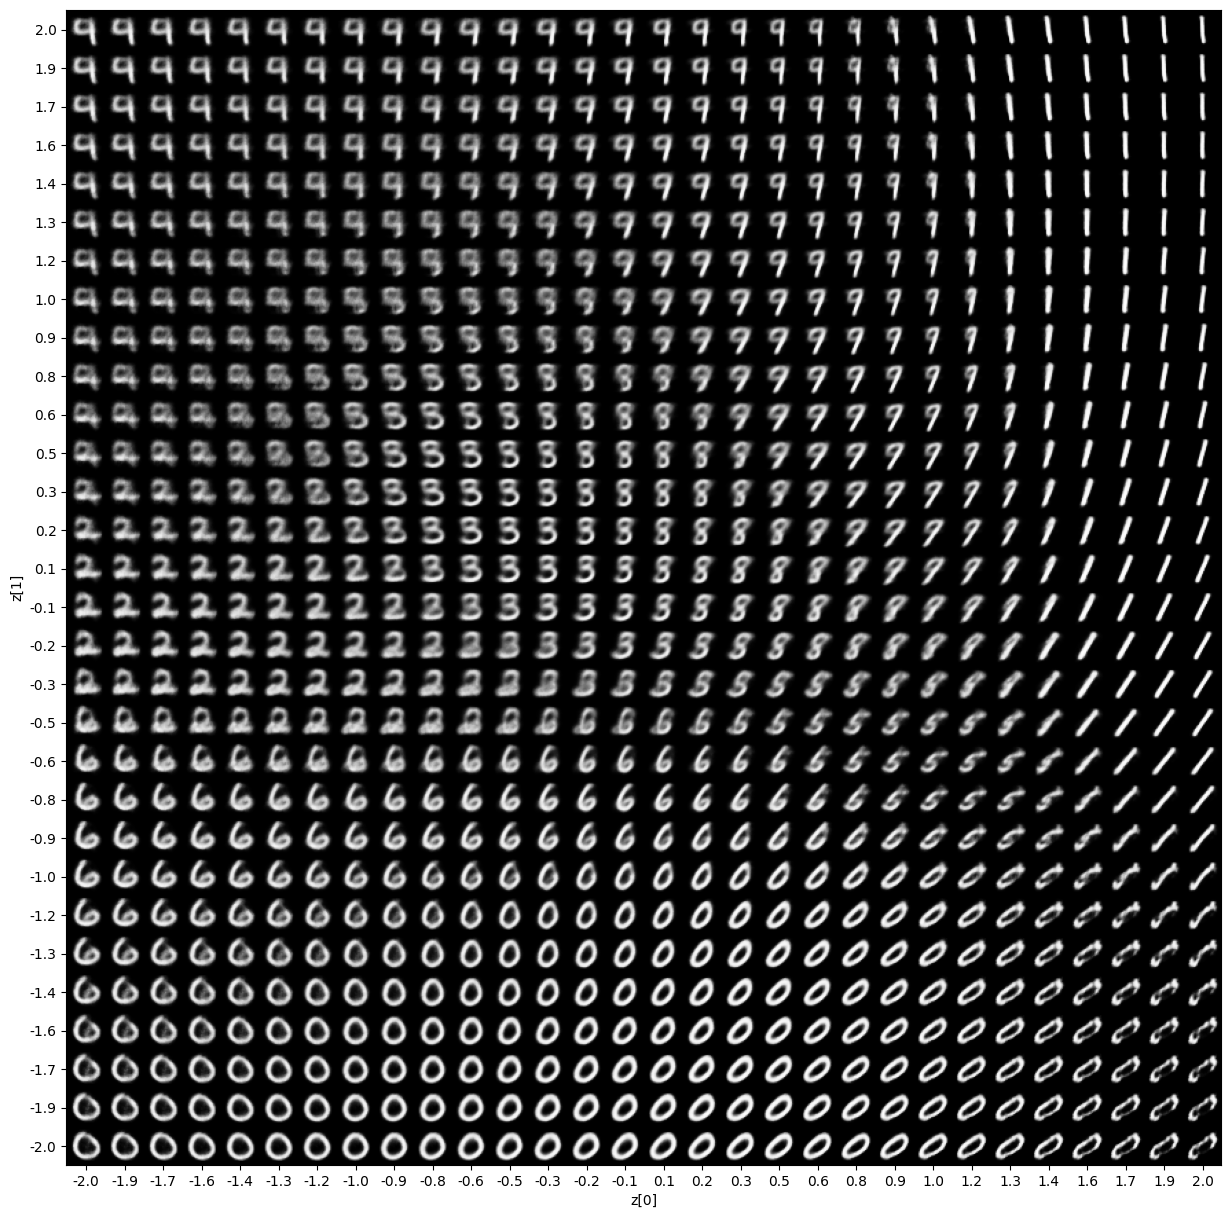

In [26]:
plot_latent_space(scale=2.0, n=30)

###### VQ-VAE

In [20]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
imgs = torch.stack([trainImageData[i] for i in range(len(trainImageData))])
data_var = 0.05 # torch.var(imgs)

In [21]:
encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())

model = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim, 
                                 nEmbeddings=n_embeds, beta=beta,
                                 data_var=data_var).to(device)

In [22]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model.train()
    encoderParams = list(model.encoder.parameters())

    losses = model.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

In [25]:
learning_rate = 1e-6
batch_size = 64
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=1., mode='min', restoreBestWeights=True)

In [52]:
batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model, batch)

recon grad norm (encoder): 26.8055
vq grad norm (encoder):    449.8086
ratio reconGradNorm/vqGradNorm -> suggested data_var: 0.0596


In [27]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vqvae/',
                checkPointName='vqvae_16_10',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 8279.273438 reconLoss: 162.869904 codeLoss: 2510.937500 commLoss: 2510.937500 vqLoss: 5021.875000[ 6400/60000]
totalLoss: 8201.070312 reconLoss: 159.765472 codeLoss: 2502.880615 commLoss: 2502.880615 vqLoss: 5005.761230[12800/60000]
totalLoss: 8160.989258 reconLoss: 158.560562 codeLoss: 2494.889160 commLoss: 2494.889160 vqLoss: 4989.778320[19200/60000]
totalLoss: 8116.473145 reconLoss: 157.131958 codeLoss: 2486.916992 commLoss: 2486.916992 vqLoss: 4973.833984[25600/60000]
totalLoss: 8047.374023 reconLoss: 154.494781 codeLoss: 2478.739258 commLoss: 2478.739258 vqLoss: 4957.478516[32000/60000]
totalLoss: 7999.679199 reconLoss: 152.868286 codeLoss: 2471.156738 commLoss: 2471.156738 vqLoss: 4942.313477[38400/60000]
totalLoss: 7933.449219 reconLoss: 150.392105 codeLoss: 2462.803467 commLoss: 2462.803467 vqLoss: 4925.606934[44800/60000]
totalLoss: 7922.962891 reconLoss: 150.755402 codeLoss: 2453.927490 commLoss: 2453.927490 vqLoss: 4907.8549

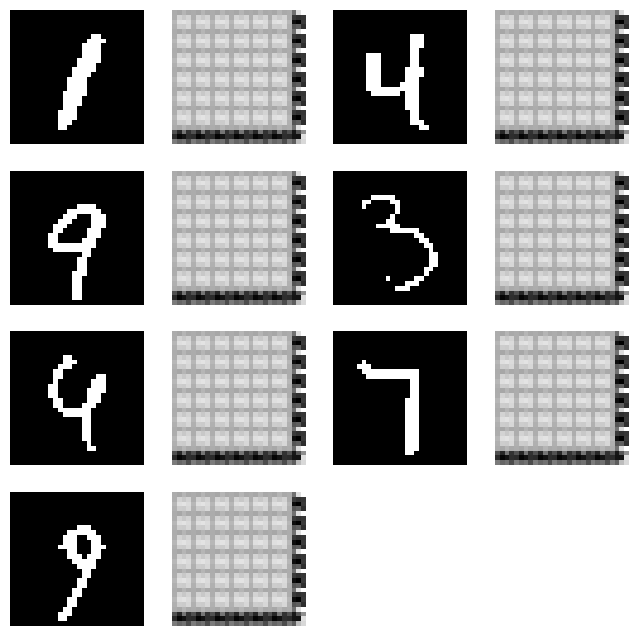

In [50]:
nCols = 4
nRows = 4

figure = plt.figure(figsize=(8, 8))
model.eval()

with torch.no_grad():
    for i in range(1, 8):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 2 * i - 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        figure.add_subplot(nRows, nCols, 2 * i)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

###### Autoencoding VAE

In [6]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [7]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.98).to(device)

In [8]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_avae/',
                checkPointName='avae_98',
                validDataLoader=validLoader)

Epoch 1
-------------------------------
totalLoss: 205.386856 reconLoss: 197.618652 klLoss: 3.840798 condLoss: 3.927404[12800/60000]
totalLoss: 191.976883 reconLoss: 184.818970 klLoss: 3.985865 condLoss: 3.172047[25600/60000]
totalLoss: 185.626633 reconLoss: 178.507294 klLoss: 4.174019 condLoss: 2.945311[38400/60000]
totalLoss: 175.131409 reconLoss: 167.852509 klLoss: 4.471026 condLoss: 2.807873[51200/60000]
Validation Error: 172.873199
Epoch 2
-------------------------------
totalLoss: 172.901718 reconLoss: 165.792419 klLoss: 4.306739 condLoss: 2.802560[12800/60000]
totalLoss: 172.585907 reconLoss: 165.392609 klLoss: 4.451108 condLoss: 2.742193[25600/60000]
totalLoss: 170.120682 reconLoss: 162.798447 klLoss: 4.625353 condLoss: 2.696877[38400/60000]
totalLoss: 169.880600 reconLoss: 162.561447 klLoss: 4.581447 condLoss: 2.737707[51200/60000]
Validation Error: 165.342987
Epoch 3
-------------------------------
totalLoss: 157.291687 reconLoss: 149.929352 klLoss: 4.586903 condLoss: 2.77544

In [10]:
# inference
def plot_latent_space(n=30, figsize=15, scale=1.0):
    # display a n*n 2D manifold of digits
    digit_size = 28
    
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

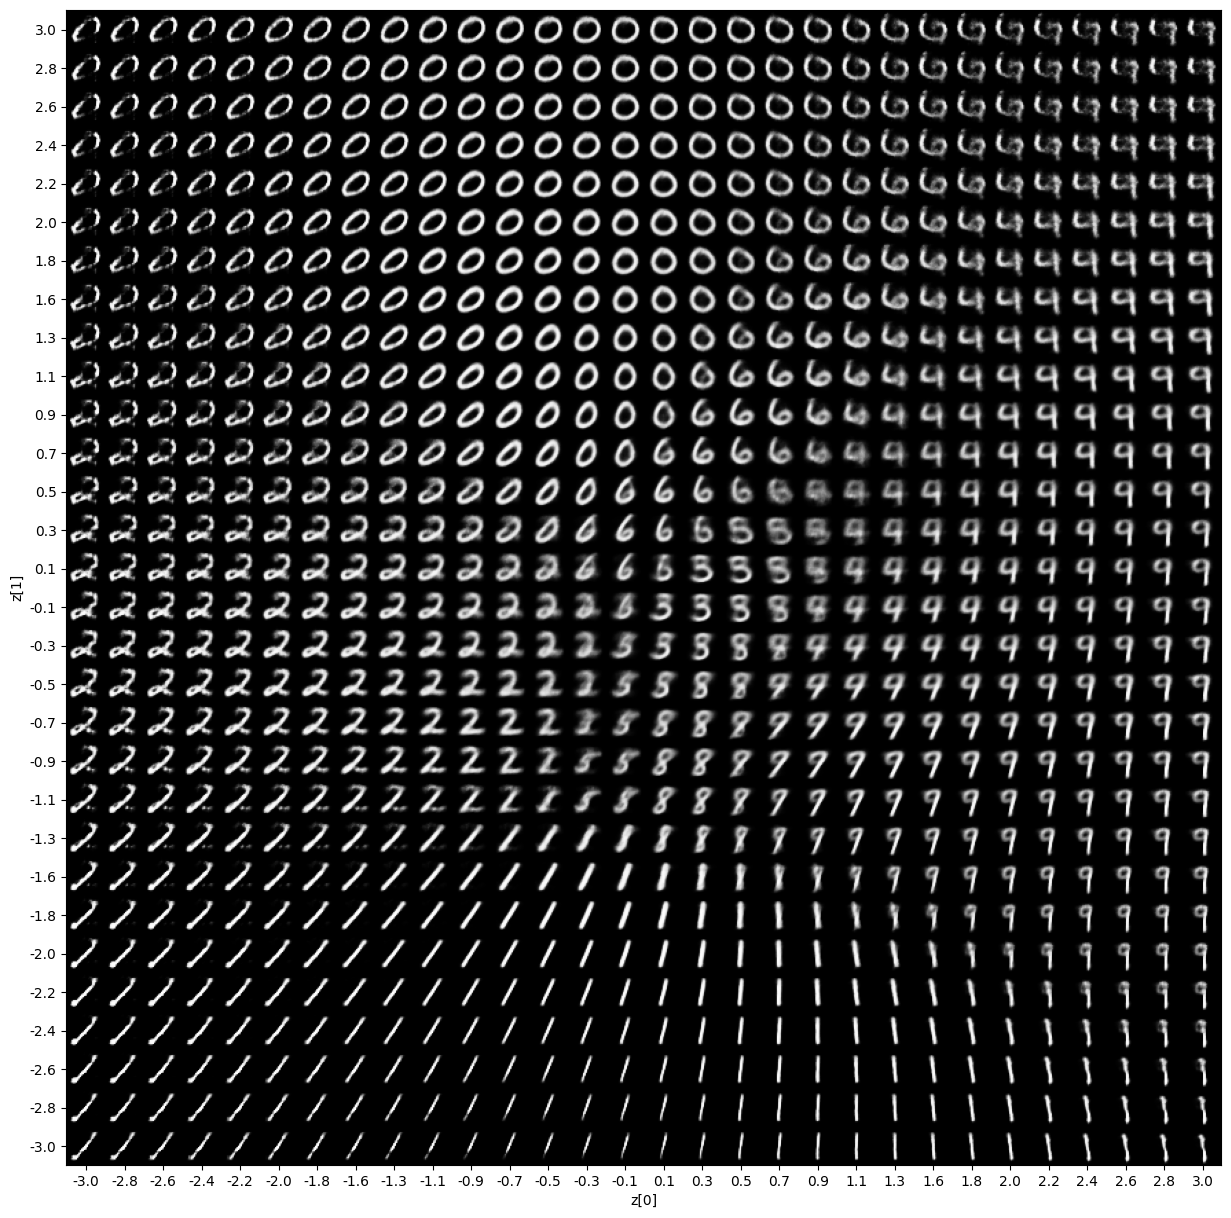

In [13]:
plot_latent_space(scale=3.0, n=30)